## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [3]:
dataset_previous = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_previous = dataset_previous[dataset_previous.year.isin([2020, 2021, 2022, 2023])].copy()
dataset_previous.reset_index(drop=True, inplace=True)

dataset_previous.head()

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2020-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2020,0.348940,0.123193,-0.297578,-0.123193,0.347467,0.121492,-0.296199,-0.121492,0.074134,0.079041,0.076301,0.079041,7.801562,-0.766364,3.517599,7.801562,NaN,NaN,NaN,-0.766364,NaN,NaN,NaN,3.517599,NaN,NaN,NaN,1.515954,23.409285,24.372446,46.858927,46.994569,31.069182,1.002232,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,20,30,12,12,1,6,7,2,-4.915346,11.774591,46.994569,0,15.833333,19.500000,47.560976,823.333947,37.0,-4.0,41.0,10.500000,23.500000,26.0,6.000000,1261.0,263.0,39.0,60.179047,435.0,193.0,207.0,384.0,14936.0,69399.0,30620.0,114955.0,14081.0,67437.0,35957.0,117475.0,2452.45,8644.0,7197.0
1,2020-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2020,0.402491,0.096085,-0.346442,-0.096085,0.387324,0.089041,-0.335262,-0.089041,0.062784,0.068748,0.053882,0.068748,9.322443,-1.093011,4.114716,9.322443,NaN,NaN,NaN,-1.093011,NaN,NaN,NaN,4.114716,NaN,NaN,NaN,0.458686,6.431028,6.540200,14.134362,14.219251,31.003584,1.000116,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.961398,14.368781,14.219251,0,17.291667,22.416667,48.731884,894.035370,42.0,-4.0,46.0,15.833333,25.666667,28.5,7.000000,1005.0,205.0,14.0,63.318531,413.0,155.0,177.0,202.0,21482.0,85156.0,29351.0,135989.0,20120.0,88927.0,35248.0,144295.0,3864.93,4121.0,5185.0
2,2020-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2020,0.377168,0.266144,-0.298038,-0.266144,0.375027,0.250464,-0.300058,-0.250464,0.073576,0.073545,0.066688,0.073545,8.316245,1.484360,4.900303,8.316245,NaN,NaN,NaN,1.484360,NaN,NaN,NaN,4.900303,NaN,NaN,NaN,0.712866,8.573109,9.350907,21.862296,22.098855,31.000000,1.000000,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.0,1.0,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144

In [4]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2024.csv", encoding = enc)
dataset_monthly.head()

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2024,0.334221,0.159408,-0.277486,-0.159408,0.326529,0.154023,-0.270094,-0.154214,0.068113,0.071497,0.069693,0.071539,8.239980,2.754859,5.497419,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,3.772496,1.491260,15.810806,116.658697,116.947373,491.493711,15.854636,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373,0,17.7,17.2,44.102564,815.543445,37.0,-2.0,39.0,8.166667,27.333333,27.333333,8.166667,445.0,116.0,0.0,103.523768,270.0,0.0,0.0,270.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2024,0.411374,0.149866,-0.347088,-0.149866,0.405401,0.145257,-0.342477,-0.145257,0.065402,0.071927,0.058498,0.071927,10.064603,3.168784,6.616693,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,1.828530,3.117468,17.913520,55.938405,56.684445,508.763441,16.411724,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445,0,19.4,21.2,48.181818,884.370460,42.0,-2.0,44.0,16.666667,29.833333,29.833333,9.000000,412.0,94.0,0.0,93.859339,256.0,0.0,0.0,197.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2024,0.397821,0.237224,-0.313479,-0.237224,0.400174,0.234837,-0.318410,-0.234837,0.068333,0.069368,0.065917,0.069368,10.133658,5.566575,7.850116,10.133658,12.615667,15.692800,22.897291,5.566575,6.373015,7.483881,11.991336,7.850116,9.494341,11.588341,17.444313,2.364135,4.172262,18.432752,71.336729,73.288175,87.030928,2.807449,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.0,1.0,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1

In [5]:
merged_df = pd.concat([dataset_previous, dataset_monthly], axis=0)
merged_df.reset_index(drop=True, inplace=True)

In [6]:
merged_df

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2020-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2020,0.348940,0.123193,-0.297578,-0.123193,0.347467,0.121492,-0.296199,-0.121492,0.074134,0.079041,0.076301,0.079041,7.801562,-0.766364,3.517599,7.801562,NaN,NaN,NaN,-0.766364,NaN,NaN,NaN,3.517599,NaN,NaN,NaN,1.515954,23.409285,24.372446,46.858927,46.994569,31.069182,1.002232,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,20,30,12,12,1,6,7,2,-4.915346,11.774591,46.994569,0,15.833333,19.500000,47.560976,823.333947,37.0,-4.0,41.0,10.500000,23.500000,26.000000,6.000000,1261.0,263.0,39.0,60.179047,435.0,193.0,207.0,384.0,14936.0,69399.0,30620.0,114955.0,14081.0,67437.0,35957.0,117475.0,2452.45,8644.0,7197.0
1,2020-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2020,0.402491,0.096085,-0.346442,-0.096085,0.387324,0.089041,-0.335262,-0.089041,0.062784,0.068748,0.053882,0.068748,9.322443,-1.093011,4.114716,9.322443,NaN,NaN,NaN,-1.093011,NaN,NaN,NaN,4.114716,NaN,NaN,NaN,0.458686,6.431028,6.540200,14.134362,14.219251,31.003584,1.000116,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.961398,14.368781,14.219251,0,17.291667,22.416667,48.731884,894.035370,42.0,-4.0,46.0,15.833333,25.666667,28.500000,7.000000,1005.0,205.0,14.0,63.318531,413.0,155.0,177.0,202.0,21482.0,85156.0,29351.0,135989.0,20120.0,88927.0,35248.0,144295.0,3864.93,4121.0,5185.0
2,2020-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2020,0.377168,0.266144,-0.298038,-0.266144,0.375027,0.250464,-0.300058,-0.250464,0.073576,0.073545,0.066688,0.073545,8.316245,1.484360,4.900303,8.316245,NaN,NaN,NaN,1.484360,NaN,NaN,NaN,4.900303,NaN,NaN,NaN,0.712866,8.573109,9.350907,21.862296,22.098855,31.000000,1.000000,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.0,1.0,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246

<Axes: >

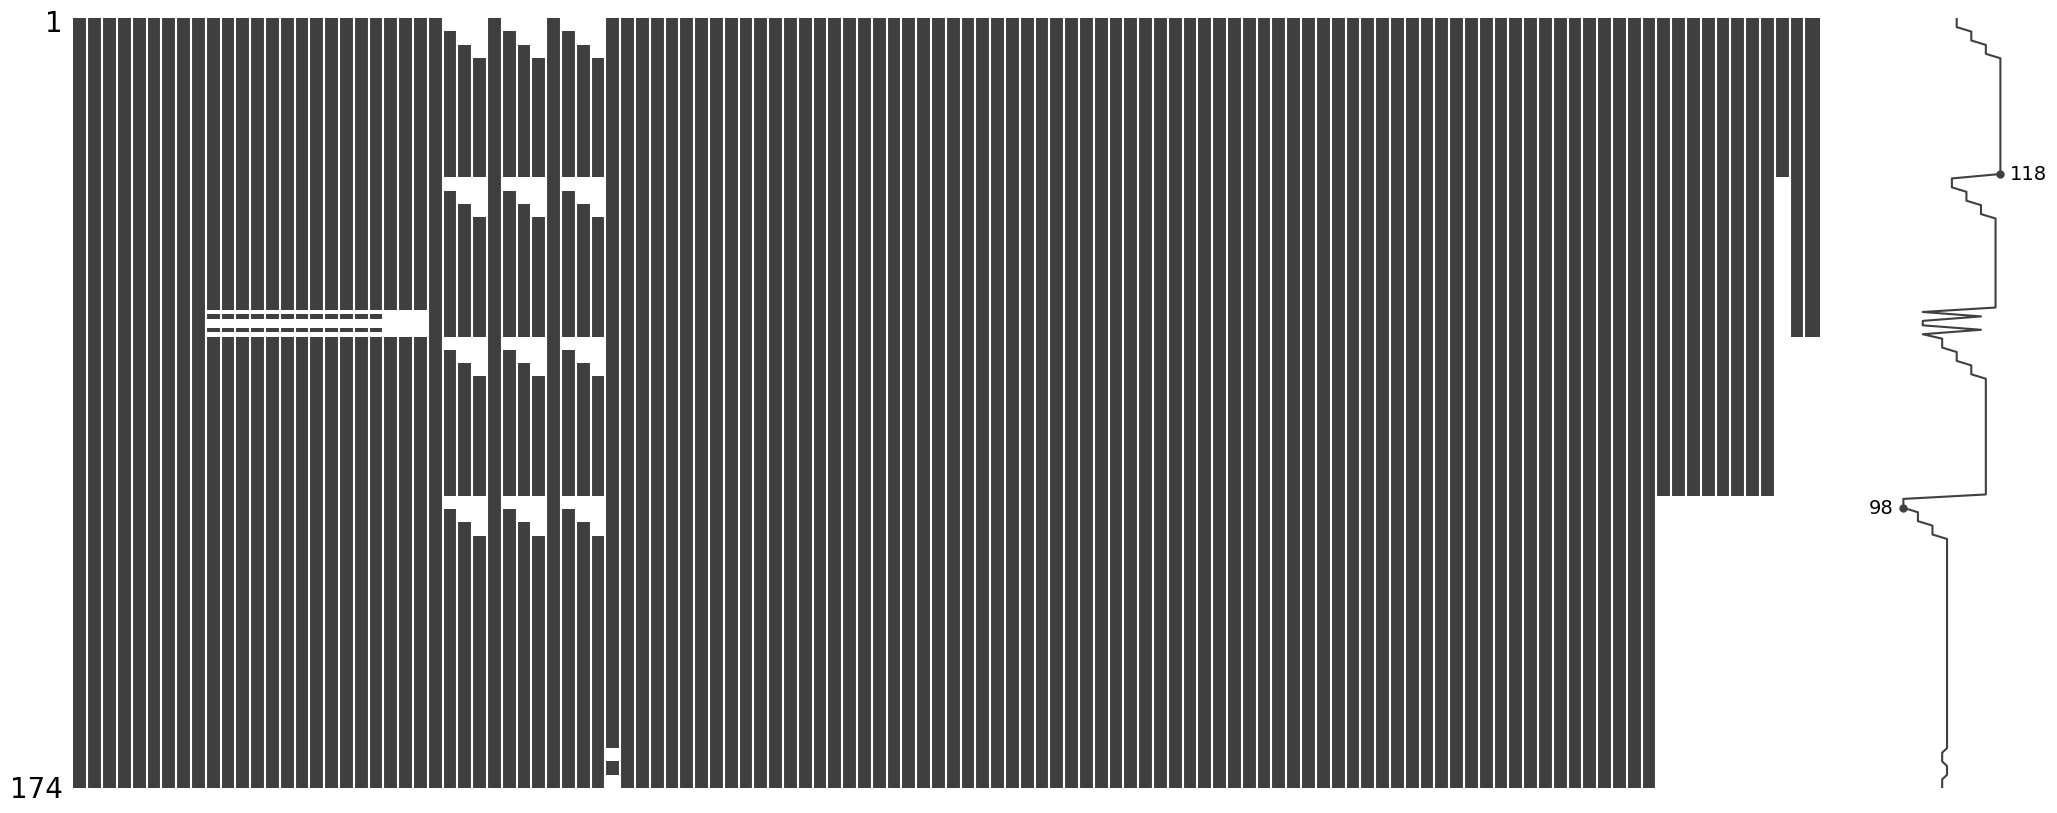

In [7]:
missingno.matrix(merged_df)

In [8]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_LT15']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_LT15']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [9]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y15-64']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y15-64']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [10]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_GE65']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_GE65']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [11]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [12]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_LT15']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_LT15']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [13]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y15-64']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y15-64']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [14]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_GE65']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_GE65']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [15]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = merged_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

merged_df[imputed_columns] = imputed_data[imputed_columns]

In [19]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','monthly_lst_min','monthly_lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'mosq_pred_acc','mosq_pred_mean',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min',
 'distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'cases']

In [20]:
merged_df = merged_df[desired_order].copy()

In [21]:
years = merged_df.year.unique()
months =  merged_df[merged_df.year == 2024].month.unique()
nuts3_units = merged_df.NUTS3_ID.unique()

In [22]:
years

array([2020, 2021, 2022, 2023, 2024], dtype=int64)

In [23]:
months

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int64)

In [24]:
years[1:]

array([2021, 2022, 2023, 2024], dtype=int64)

In [25]:
data = []

for year in years[1:]:
    for month in months:
        for region in nuts3_units:
            df_regional = merged_df.loc[(merged_df['NUTS3_ID'] == region)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'NUTS3_ID': region, 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_prev_month.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_prev_month.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_prev_month.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_prev_month.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_prev_month.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_prev_month.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_prev_month.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_prev_month.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_prev_month.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_prev_month.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_prev_month.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_prev_month.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['monthly_lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['monthly_lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_prev_month.iloc[0]['acc_rainfall_jan'],

                        'mosq_pred_acc': df_prev_month.iloc[0]['mosq_pred_acc'],
                        'mosq_pred_mean': df_prev_month.iloc[0]['mosq_pred_mean'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_prev_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_prev_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_prev_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_prev_year.iloc[0]['lc_type1'],
                        'lc_type2': df_prev_year.iloc[0]['lc_type2'],
                        'lc_type3': df_prev_year.iloc[0]['lc_type3'],
                        'lc_type4': df_prev_year.iloc[0]['lc_type4'],
                        'lc_type5': df_prev_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_prev_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_prev_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_prev_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_prev_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_prev_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_prev_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_prev_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_prev_year.iloc[0]['flow_accu_200m'],

                        'distance_to_coast_min': df_prev_year.iloc[0]['distance_to_coast_min'],
                        'distance_to_river_min': df_prev_year.iloc[0]['distance_to_river_min'],
                        'slope_mean_1km_min': df_prev_year.iloc[0]['slope_mean_1km_min'],
                        'aspect_mean_200m_min': df_prev_year.iloc[0]['aspect_mean_200m_min'],
                        'elevation_mean_1km_min': df_prev_year.iloc[0]['elevation_mean_1km_min'],
                        'hillshade_mean_1km_min': df_prev_year.iloc[0]['hillshade_mean_1km_min'],
                        'fs_area_1km_min': df_prev_year.iloc[0]['fs_area_1km_min'],
                        'flow_accu_200m_min': df_prev_year.iloc[0]['flow_accu_200m_min'],

                        'distance_to_coast_max': df_prev_year.iloc[0]['distance_to_coast_max'],
                        'distance_to_river_max': df_prev_year.iloc[0]['distance_to_river_max'],
                        'slope_mean_1km_max': df_prev_year.iloc[0]['slope_mean_1km_max'],
                        'aspect_mean_200m_max': df_prev_year.iloc[0]['aspect_mean_200m_max'],
                        'elevation_mean_1km_max': df_prev_year.iloc[0]['elevation_mean_1km_max'],
                        'hillshade_mean_1km_max': df_prev_year.iloc[0]['hillshade_mean_1km_max'],
                        'fs_area_1km_max': df_prev_year.iloc[0]['fs_area_1km_max'],
                        'flow_accu_200m_max': df_prev_year.iloc[0]['flow_accu_200m_max'],

                        'distance_to_coast_std': df_prev_year.iloc[0]['distance_to_coast_std'],
                        'distance_to_river_std': df_prev_year.iloc[0]['distance_to_river_std'],
                        'slope_mean_1km_std': df_prev_year.iloc[0]['slope_mean_1km_std'],
                        'aspect_mean_200m_std': df_prev_year.iloc[0]['aspect_mean_200m_std'],
                        'elevation_mean_1km_std': df_prev_year.iloc[0]['elevation_mean_1km_std'],
                        'hillshade_mean_1km_std': df_prev_year.iloc[0]['hillshade_mean_1km_std'],
                        'fs_area_1km_std': df_prev_year.iloc[0]['fs_area_1km_std'],
                        'flow_accu_200m_std': df_prev_year.iloc[0]['flow_accu_200m_std'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],
                    
                        'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

In [26]:
merged_df[(merged_df['NUTS3_ID'] == 'EL611') & (merged_df['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_NAME'])

,dt_placement,NUTS3_ID,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,cases
108,2023-01,EL611,21.720538,39.507246,1,2023,0.317026,0.134502,-0.252518,-0.134502,0.296231,0.134926,-0.235937,-0.134926,0.064177,0.073657,0.067273,0.073657,8.442297,8.442297,NaN,NaN,NaN,1.997685,1.997685,NaN,NaN,NaN,5.219991,5.219991,NaN,NaN,NaN,-0.763208,11.823333,7.873445,89.426763,207.896782,244.076785,244.076785,15.333333,17.0,42.5,782.865753,36.0,-4.0,40.0,16.333333,25.0,25.5,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,94.861635,3.060053,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.0,10.738235,0,0.0,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.67593,845.696425,11.675884,54.646084,479.17267,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,14537.0,68346.0,30036.0,112919.0,13491.0,65903.0,35332.0,114726.0,2452.45,6070.0,6292.0,0
111,2023-02,EL611,21.720538,39.507246,2,2023,0.322256,0.161641,-0.284662,-0.161641,0.308949,0.158959,-0.273964,-0.158959,0.066244,0.080145,0.057598,0.080145,9.960925,8.442297,9.960925,NaN,NaN,1.196738,1.997685,1.196473,NaN,NaN,5.578832,5.219991,5.578699,NaN,NaN,-4.181572,16.148302,1.855163,18.782468,21.746760,53.482871,296.021341,15.333333,17.0,42.5,782.865753,36.0,-4.0,40.0,16.333333,25.0,25.5,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,109.509434,3.911051,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.0,10.738235,0,0.0,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.67593,845.696425,11.675884,54.646084,479.17267,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,14537.0,68346.0,30036.0,112919.0,13491.0,65903.0,35332.0,114726.0,2452.45,6070.0,6292.0,0
114,2023-03,EL611,21.720538,39.507246,3,2023,0.383936,0.108335,-0.345430,-0.108335,0.368096,0.108165,-0.330802,-0.108165,0.066419,0.073577,0.051295,0.073577,15.827328,8.442297,9.960925,15.827328,NaN,5.066013,1.997685,1.196473,5.066013,NaN,10.446671,5.219991,5.578699,10.446671,NaN,1.529811,23.801509,2.946314,9.883296,24.157553,75.916705,387.357078,15.333333,17.0,42.5,782.865753,36.0,-4.0,40.0,16.333333,25.0,25.5,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,610.132075,19.681680,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.0,10.738235,0,0.0,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.67593,845.696425,11.675884,54.646084,479.17267,16.464355,0.147294,1426.627793,3

In [27]:
dataset_operational[(dataset_operational['NUTS3_ID'] == 'EL611') & (dataset_operational['year'] == 2024)]

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
90,EL611,2024,1,21.720538,39.507246,0.349829,0.129800,-0.279926,-0.129800,0.338639,0.125415,-0.269985,-0.125415,0.069714,0.069789,0.072988,0.069789,9.980994,8.442297,9.960925,15.827328,15.827328,4.665845,1.997685,1.196473,5.066013,5.066013,7.323419,5.219991,5.578699,10.446671,10.446671,0.808113,13.043208,1.783729,0.693578,7.213471,46.575779,2132.964332,1147.871069,37.028099,15.333333,17.0,42.5,782.865753,36.0,-4.0,40.0,16.333333,25.0,25.5,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.0,10.738235,0,0.0,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.67593,845.696425,11.675884,54.646084,479.17267,16.464355,0.147294,1426.627793,14537.0,68346.0,30036.0,112919.0,13491.0,65903.0,35332.0,114726.0,2452.45,6070.0,6292.0,0
93,EL611,2024,2,21.720538,39.507246,0.334221,0.159408,-0.277486,-0.159408,0.326529,0.154023,-0.270094,-0.154214,0.068113,0.071497,0.069693,0.071539,8.239980,8.239980,11.270013,15.315817,23.483530,2.754859,2.754859,3.885821,5.499430,10.308722,5.497419,5.497419,7.577917,10.407623,16.896126,-2.440881,13.502390,3.772496,1.491260,15.810806,116.658697,116.947373,491.493711,15.854636,15.333333,17.0,42.5,782.865753,36.0,-4.0,40.0,16.333333,25.0,25.5,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.0,10.738235,0,0.0,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.67593,845.696425,11.675884,54.646084,479.17267,16.464355,0.147294,1426.627793,14537.0,68346.0,30036.0,112919.0,13491.0,65903.0,35332.0,114726.0,2452.45,6070.0,6292.0,0
96,EL611,2024,3,21.720538,39.507246,0.369467,0.109724,-0.328050,-0.109724,0.360121,0.108430,-0.321235,-0.108430,0.062147,0.067764,0.057353,0.067764,11.270013,8.239980,11.270013,15.315817,23.483530,3.885821,2.754859,3.885821,5.499430,10.308722,7.577917,5.497419,7.577917,10.407623,16.896126,-1.664151,14.408302,2.260099,38.804018,40.941763,65.578676,182.490245,778.399371,26.841358,15.333333,17.0,42.5,782.865753,36.0,-4.0,40.0,16.333333,25.0,25.5,6.0,2126.0,821.0,20.0,121.562199,1114.0,245.0,881.0,348.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.0,10.738235,0,0.0,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.10097

In [28]:
dataset_operational = dataset_operational[dataset_operational.year == 2024]

<Axes: >

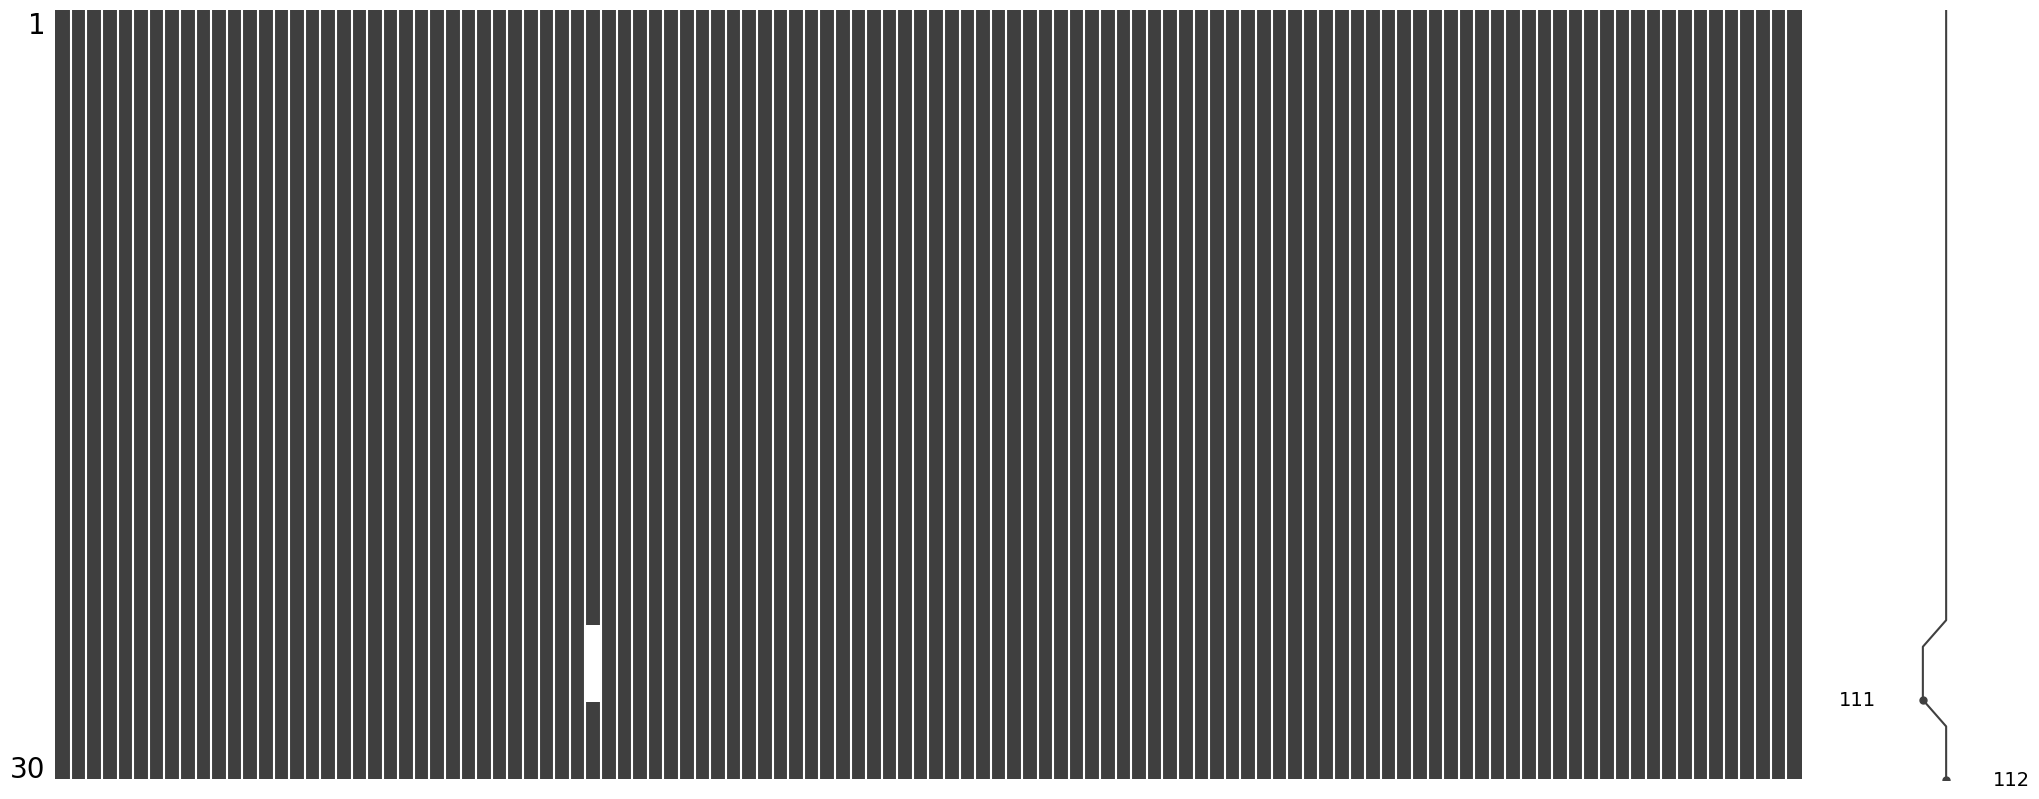

In [29]:
missingno.matrix(dataset_operational)

In [30]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
34,rainfall_mean,10.0


<Axes: >

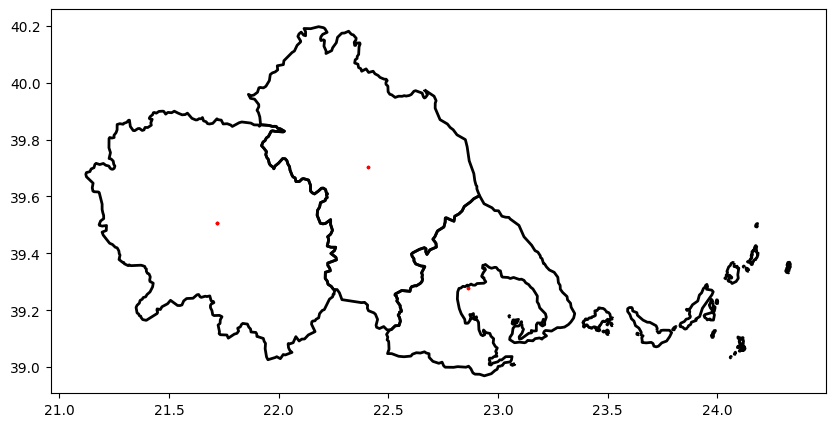

In [31]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_previous[['NUTS3_ID']], geometry=gpd.points_from_xy(dataset_previous.x, dataset_previous.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [32]:
dataset_operational.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2024.csv", encoding = enc, index = False)